## Connecting drive with google colab

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the Review dataset

In [ ]:
import pandas as pd


data = pd.read_csv('/content/drive/MyDrive/Sentiment_analysis/Reviews.csv')
print(f"Original Dataset Size: {df.shape[0]} rows.")

Original Dataset Size: 568454 rows.


In [ ]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Cleaning Data (Handling missing values)

In [ ]:
data.dropna(subset=['Text', 'Score'], inplace=True)

## Confirming the data size

In [ ]:
data.size

5684540

## Feature Engineering (Translating Stars to Sentiment)

In [ ]:
data = data[data['Score'] != 3]
data['Sentiment'] = data['Score'].apply(lambda x: 1 if x > 3 else 0)

In [ ]:
data.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,1
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,1
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,1


## Taking a random, balanced sample of 20,000 reviews to choose th best algorithm

In [ ]:
positive_reviews = df[df['Sentiment'] == 1].sample(n=10000, random_state=42)
negative_reviews = df[df['Sentiment'] == 0].sample(n=10000, random_state=42)
data_balanced = pd.concat([positive_reviews, negative_reviews]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal Cleaned & Balanced Dataset Size: {data_balanced.shape[0]} rows.")


Final Cleaned & Balanced Dataset Size: 20000 rows.


## Importing all necessary libraries and Algorithms

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

defining X and Y and spliting data into train and test set

In [ ]:
X = data_balanced['Text']
y = data_balanced['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Vectorizing Text (TF-IDF), converting the top 5,000 words into a mathematical matrix

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## We train all the three models together and compare their accuracies.

Training Logistic Regression...
Logistic Regression Results:
   Speed: 0.05 seconds

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.85      0.88      0.86      1945
Positive (1)       0.89      0.85      0.87      2055

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



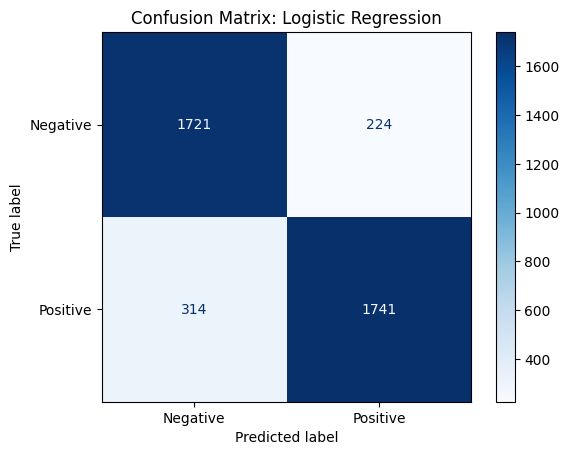

Training Naive Bayes (Multinomial)...
Naive Bayes (Multinomial) Results:
   Speed: 0.01 seconds

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.84      0.85      0.85      1945
Positive (1)       0.86      0.85      0.85      2055

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



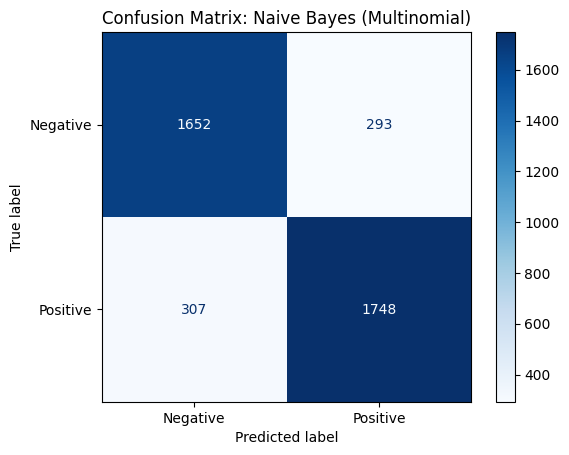

Training Random Forest...
Random Forest Results:
   Speed: 17.36 seconds

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.85      0.84      1945
Positive (1)       0.86      0.84      0.85      2055

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



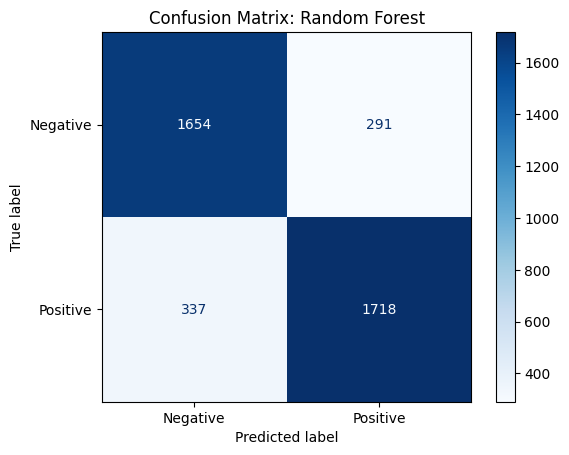

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Naive Bayes (Multinomial)": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# We loop through, train each one, and record their time and accuracy
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()

    # Train the model
    model.fit(X_train_vec, y_train)

    # Test the model
    predictions = model.predict(X_test_vec)

    # Stop the clock and calculate accuracy
    end_time = time.time()
    time_taken = end_time - start_time
    accuracy = accuracy_score(y_test, predictions) * 100

    print(f"{name} Results:")
    print(f"   Speed: {time_taken:.2f} seconds\n")


    print("Detailed Classification Report:")
    print(classification_report(y_test, predictions, target_names=['Negative (0)', 'Positive (1)']))

    # Draw the Confusion Matrix in just TWO simple lines of code!
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        display_labels=['Negative', 'Positive'],
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

print("="*40)

## Training a Logistic Algorithm with 100, 000 rows from the dataset

In [ ]:
import pandas as pd
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# load the data
positive_prod = data[data['Sentiment'] == 1].sample(n=50000, random_state=42)
negative_prod = data[data['Sentiment'] == 0].sample(n=50000, random_state=42)

# Combine and shuffle them into our final production dataset
data_prod = pd.concat([positive_prod, negative_prod]).sample(frac=1, random_state=42).reset_index(drop=True)

X_prod = data_prod['Text']
y_prod = data_prod['Sentiment']

# Now the 'make_pipeline'
final_model = make_pipeline(
    TfidfVectorizer(max_features=5000, stop_words='english'),
    LogisticRegression(max_iter=500, random_state=42)
)

print(f"Training Final Model on {len(data_prod)} reviews..")
final_model.fit(X_prod, y_prod)

print("\nModel Training Complete!")
# final accuracy
final_accuracy = final_model.score(X_prod, y_prod) * 100
print(f"Final Production Training Accuracy: {final_accuracy:.2f}%")

print("\n5Exporting the AI Brain...")
# We save the entire pipeline (Translator + Brain) as a single file
model_filename = 'review_rescue_model.pkl'
joblib.dump(final_model, model_filename)

print(f"✅ SUCCESS! Model saved as '{model_filename}'")

Training Final Model on 100000 reviews..

Model Training Complete!
Final Production Training Accuracy: 90.49%

5Exporting the AI Brain...
✅ SUCCESS! Model saved as 'review_rescue_model.pkl'


## Introducing N-grams to improve accuracy

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

positive_prod = data[data['Sentiment'] == 1].sample(n=50000, random_state=42)
negative_prod = data[data['Sentiment'] == 0].sample(n=50000, random_state=42)

# Combine and shuffle
data_prod = pd.concat([positive_prod, negative_prod]).sample(frac=1, random_state=42).reset_index(drop=True)

X_prod = data_prod['Text']
y_prod = data_prod['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X_prod, y_prod, test_size=0.2, random_state=42)

final_model = make_pipeline(
    # ngram_range=(1,2) tells it to learn 1-word and 2-word phrases ("terrible" AND "not good")
    # max_features=10000 gives it a bigger dictionary to store those phrases
    TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2)),

    # C=1.5 gives the AI a tiny bit more freedom to adjust its mathematical weights
    LogisticRegression(max_iter=500, random_state=42, C=1.5)
)

final_model.fit(X_train, y_train)

print("\n" + "="*40)
print("FINAL PRODUCTION CLASSIFICATION REPORT")
print("="*40)
# We test it on the 20,000 hidden reviews
predictions = final_model.predict(X_test)
true_accuracy = accuracy_score(y_test, predictions) * 100

print(f"True Production Accuracy: {true_accuracy:.2f}%\n")
print(classification_report(y_test, predictions, target_names=['Negative (0)', 'Positive (1)']))

print("\n5. Exporting the AI Brain...")
model_filename = 'review_rescue_model.pkl'
joblib.dump(final_model, model_filename)


FINAL PRODUCTION CLASSIFICATION REPORT
True Production Accuracy: 90.41%

              precision    recall  f1-score   support

Negative (0)       0.90      0.91      0.91     10078
Positive (1)       0.91      0.90      0.90      9922

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000


5. Exporting the AI Brain...


['review_rescue_model.pkl']

## Confussion Matrix

Generating Final Production Confusion Matrix...


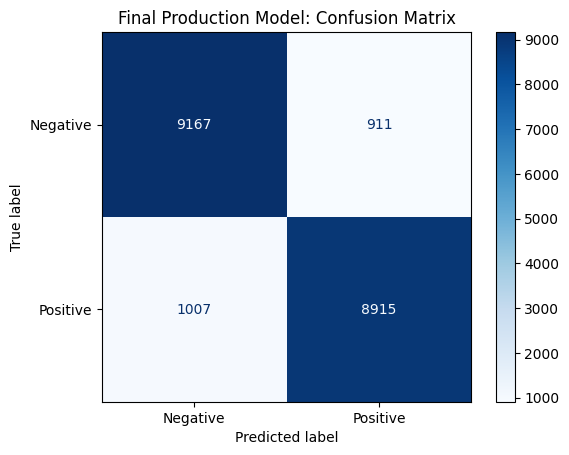

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Generating Final Production Confusion Matrix...")

# Draw the matrix using the test data from the previous cell
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['Negative', 'Positive'],
    cmap='Blues'
)

plt.title("Final Production Model: Confusion Matrix")
plt.show()

## Testing the model with unseen data

In [ ]:
import joblib

# Load the saved model
model = joblib.load('review_rescue_model.pkl')

# 2. Write a few fake reviews to test it
my_test_reviews = [
    "Absolutely love this product! It arrived early and works perfectly.",
    "The customer service team was very helpful and solved my issue in minutes.",
    "Highly recommend. Five stars for the amazing food and friendly staff.",
    "This is the best purchase I have made all year. Great quality and affordable.",
    "Very satisfied with the app. It runs smoothly without any lag.",

    # --- CLEARLY NEGATIVE ---
    "Terrible experience. The item was broken when I opened the box.",
    "Do not buy this. It is a complete waste of money and stopped working after one day.",
    "The food was cold, tasteless, and took over an hour to arrive. Very disappointed.",
    "Worst customer service ever. They hung up on me and refused to give a refund.",
    "The app keeps crashing every time I try to log in. Completely useless."
]

predictions = model.predict(my_test_reviews)

# Let's grab the exact confidence percentages
probabilities = model.predict_proba(my_test_reviews)

# Print out the results
for i in range(len(my_test_reviews)):
    review_text = my_test_reviews[i]
    pred = predictions[i]

    # probabilities[i] gives us two numbers: [Chance of 0, Chance of 1]
    # We grab the highest probability to see how confident the AI is
    confidence = max(probabilities[i]) * 100

    status = "🟢 POSITIVE" if pred == 1 else "🔴 NEGATIVE / CRITICAL"

    print(f"Review: '{review_text}'")
    print(f"--> Result: {status} (Confidence: {confidence:.2f}%)\n")

Review: 'Absolutely love this product! It arrived early and works perfectly.'
--> Result: 🟢 POSITIVE (Confidence: 98.35%)

Review: 'The customer service team was very helpful and solved my issue in minutes.'
--> Result: 🟢 POSITIVE (Confidence: 58.81%)

Review: 'Highly recommend. Five stars for the amazing food and friendly staff.'
--> Result: 🟢 POSITIVE (Confidence: 99.85%)

Review: 'This is the best purchase I have made all year. Great quality and affordable.'
--> Result: 🟢 POSITIVE (Confidence: 99.95%)

Review: 'Very satisfied with the app. It runs smoothly without any lag.'
--> Result: 🟢 POSITIVE (Confidence: 88.86%)

Review: 'Terrible experience. The item was broken when I opened the box.'
--> Result: 🔴 NEGATIVE / CRITICAL (Confidence: 99.94%)

Review: 'Do not buy this. It is a complete waste of money and stopped working after one day.'
--> Result: 🔴 NEGATIVE / CRITICAL (Confidence: 95.97%)

Review: 'The food was cold, tasteless, and took over an hour to arrive. Very disappointed.'